<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/gas_turbine_emissions_and_process_power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gas turbine emissions and process power with NeqSim

**Audience.** Process, mechanical, energy, and emissions engineers who want to connect
simulated equipment power to fuel-gas demand and direct combustion emissions.

**Prerequisites.** Basic Python, pressure and temperature, compressor efficiency, and
energy-rate units are useful. No local NeqSim checkout or proprietary data is required.


## Learning objectives

After completing the notebook, you can:

1. define and flash the original six-component SRK fuel/process gas;
2. reproduce the original compressor and emissions screening calculation;
3. distinguish an ideal isentropic compressor from a realistic efficiency assumption;
4. use the current `GasTurbineCatalog`, `GasTurbineUnit`, performance map, emissions,
   ambient correction, and degradation functionality;
5. connect a NeqSim compressor as a gas-turbine power consumer;
6. compare constant-factor screening with native load-dependent turbine calculations; and
7. validate mass, energy, capacity, and expected-trend checks before reuse.


## Preservation checklist

The previous notebook had four substantive examples and one substantive figure. All are
retained and integrated:

- the six-component SRK gas at 25 °C and 55 bara;
- the 10,000 kg/h compressor from 55 to 120 bara;
- the 0.32 efficiency, 48 MJ/kg LHV, 2.75 kg CO₂/kg fuel, and 8,000 h/year screen;
- the original shaft-power, fuel-rate, and annual-CO₂ table; and
- the four-point 0.28–0.40 efficiency-versus-annual-CO₂ line figure.

The original figure is recomputed with NeqSim 3.16.0. Its teaching message and recognizable
line presentation remain. New figures add workflow, catalog, native performance, ambient
and degradation, and final-application views.


## 1. Clean Colab setup

The setup installs the latest public PyPI package only when `neqsim` is absent. It does not
inject a JAR, use an editable checkout, or require a runtime restart. Runtime versions are
printed for reproducibility.


In [1]:
import importlib.metadata
import platform
import subprocess
import sys

try:
    import neqsim
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )
    import neqsim

neqsim_version = importlib.metadata.version("neqsim")
java_version = platform.java_ver()[0]

if not java_version:
    java_version = subprocess.check_output(
        ["java", "-version"],
        stderr=subprocess.STDOUT,
        text=True,
    ).splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {platform.python_version()}")
print(f"Java runtime: {java_version}")


NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyBboxPatch

from neqsim import jneqsim

plt.style.use("seaborn-v0_8-whitegrid")


## 2. Engineering question and workflow

An export compressor demands shaft power. A gas turbine converts fuel-gas chemical energy
to shaft or electrical power, with efficiency changing with load, ambient conditions, and
equipment condition. The workflow keeps process simulation, power generation, emissions,
and validation connected instead of treating emissions as a detached spreadsheet.


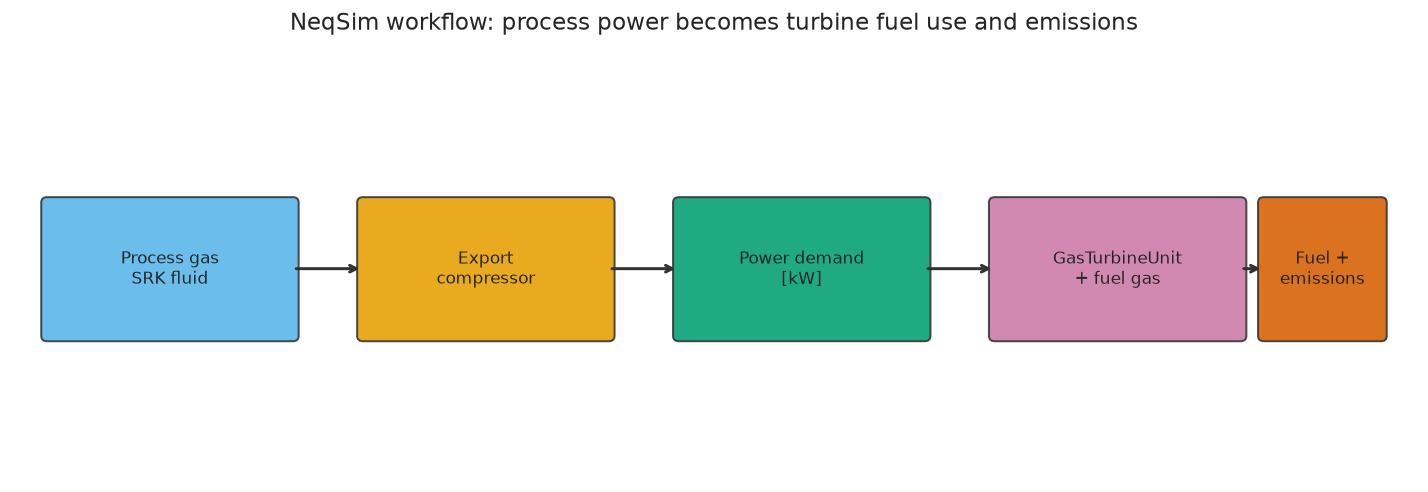

In [3]:
figure, axis = plt.subplots(figsize=(12.0, 4.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

boxes = [
    (0.3, 1.35, 2.1, 1.25, "Process gas\nSRK fluid", "#56B4E9"),
    (3.0, 1.35, 2.1, 1.25, "Export\ncompressor", "#E69F00"),
    (5.7, 1.35, 2.1, 1.25, "Power demand\n[kW]", "#009E73"),
    (8.4, 1.35, 2.1, 1.25, "GasTurbineUnit\n+ fuel gas", "#CC79A7"),
    (10.7, 1.35, 1.0, 1.25, "Fuel +\nemissions", "#D55E00"),
]

for x_position, y_position, width, height, label, color in boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.2,
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

for x_start, x_end in [(2.4, 3.0), (5.1, 5.7), (7.8, 8.4), (10.5, 10.7)]:
    axis.annotate(
        "",
        xy=(x_end, 1.98),
        xytext=(x_start, 1.98),
        arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1.8},
    )

axis.set_title(
    "NeqSim workflow: process power becomes turbine fuel use and emissions",
    fontsize=14,
    pad=14,
)
plt.tight_layout()
plt.show()


The overview is a model map, not a physical piping diagram. The compressor consumes power;
the turbine consumes a separately defined fuel stream whose composition controls the
combustion carbon factor.


## 3. Governing equations

For a compressor, actual shaft power $P$ is the isentropic power $P_s$ divided by the
isentropic efficiency $\eta_c$:

$$
P = \frac{P_s}{\eta_c}
$$

For a constant-efficiency screening calculation, fuel mass rate is:

$$
\dot{m}_f = \frac{P}{\eta_t LHV}
$$

Here $P$ is in kJ/s, turbine efficiency $\eta_t$ is dimensionless, and lower heating value
$LHV$ is in kJ/kg. Annual direct CO₂ is:

$$
m_{CO_2,y} = \dot{m}_f EF_{CO_2} t_y
$$

The native turbine model instead evaluates load fraction:

$$
L = \frac{P_{demand}}{P_{available}}
$$

and obtains heat rate, efficiency, fuel rate, exhaust, and emissions from its performance
and emissions objects. Every pressure in this notebook is absolute bara.


## 4. Assumptions and validity limits

- SRK with the classic mixing rule represents a dry, sweet natural gas.
- The original compressor has no inlet or outlet pressure loss.
- The preserved 100% compressor efficiency is an idealized reference, not a design value.
- The realistic compressor uses 78% isentropic efficiency.
- The original emissions method is a screening estimate with fixed factors.
- Native turbine catalog data are generic public NeqSim reference specifications, not a
  vendor guarantee or site acceptance curve.
- Transients, start-up fuel, maintenance flaring, upstream methane, and exported heat are
  outside the direct steady-state boundary.


## 5. Original gas assay

The mole fractions and SRK model are preserved exactly. The sum is checked before the fluid
is used. The same assay is used as process gas and as the native turbine fuel composition.


In [4]:
original_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}

composition_sum = sum(original_composition.values())
assert math.isclose(composition_sum, 1.0, abs_tol=1.0e-12)

composition_table = pd.DataFrame(
    {
        "Component": list(original_composition),
        "Mole fraction [-]": list(original_composition.values()),
    }
)
display(composition_table)
print(f"Composition sum: {composition_sum:.6f}")


Composition sum: 1.000000


,Component,Mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


In [5]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
GasTurbineCatalog = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineCatalog
)
GasTurbineUnit = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineUnit
)
GasTurbineDegradation = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineDegradation
)


def make_gas(
    temperature_c=25.0,
    pressure_bara=60.0,
    flow_kg_h=10_000.0,
):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in original_composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid


In [6]:
reference_fluid = make_gas(
    temperature_c=25.0,
    pressure_bara=55.0,
    flow_kg_h=10_000.0,
)
reference_properties = pd.DataFrame(
    [
        {
            "Temperature [°C]": reference_fluid.getTemperature("C"),
            "Pressure [bara]": reference_fluid.getPressure("bara"),
            "Mass flow [kg/h]": reference_fluid.getFlowRate("kg/hr"),
            "Molar mass [kg/mol]": reference_fluid.getMolarMass("kg/mol"),
            "Density [kg/m³]": reference_fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": (
                reference_fluid.getEnthalpy("J/kg") / 1000.0
            ),
        }
    ]
)
display(reference_properties.round(6))


,Temperature [°C],Pressure [bara],Mass flow [kg/h],Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg]
0,25.0,55.0,10000.0,0.018966,48.121583,10.435344


The property table is the reproducibility checkpoint for composition, state, and units.
A single gas phase is expected at this inlet condition.


## 6. Preserved compressor example, with the hidden assumption repaired

The previous notebook did not set compressor efficiency. NeqSim therefore returned the
ideal isentropic requirement. The function below makes efficiency explicit and returns
named streams, equipment, and balance terms for reuse.


In [7]:
def simulate_compressor(
    flow_kg_h,
    inlet_pressure_bara,
    outlet_pressure_bara,
    isentropic_efficiency,
    temperature_c=25.0,
    case_name="compressor case",
):
    fluid = make_gas(
        temperature_c=temperature_c,
        pressure_bara=inlet_pressure_bara,
        flow_kg_h=flow_kg_h,
    )
    feed = Stream(f"{case_name} feed", fluid)
    compressor = Compressor(f"{case_name} compressor", feed)
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(isentropic_efficiency)
    process = ProcessSystem(f"{case_name} process")
    process.add(feed)
    process.add(compressor)
    process.run()

    outlet = compressor.getOutletStream()
    mass_flow_kg_s = feed.getFlowRate("kg/sec")
    enthalpy_rate_change_w = mass_flow_kg_s * (
        outlet.getFluid().getEnthalpy("J/kg")
        - feed.getFluid().getEnthalpy("J/kg")
    )
    power_w = compressor.getPower("W")
    result = {
        "flow_kg_h": flow_kg_h,
        "inlet_pressure_bara": inlet_pressure_bara,
        "outlet_pressure_bara": outlet_pressure_bara,
        "isentropic_efficiency": isentropic_efficiency,
        "power_kW": power_w / 1000.0,
        "outlet_temperature_c": outlet.getTemperature("C"),
        "mass_residual_kg_h": (
            feed.getFlowRate("kg/hr")
            - outlet.getFlowRate("kg/hr")
        ),
        "energy_residual_w": power_w - enthalpy_rate_change_w,
    }
    objects = {
        "process": process,
        "feed": feed,
        "compressor": compressor,
        "outlet": outlet,
    }
    return result, objects


In [8]:
ideal_result, ideal_objects = simulate_compressor(
    flow_kg_h=10_000.0,
    inlet_pressure_bara=55.0,
    outlet_pressure_bara=120.0,
    isentropic_efficiency=1.0,
    case_name="preserved ideal",
)
realistic_result, realistic_objects = simulate_compressor(
    flow_kg_h=10_000.0,
    inlet_pressure_bara=55.0,
    outlet_pressure_bara=120.0,
    isentropic_efficiency=0.78,
    case_name="realistic",
)

compressor_comparison = pd.DataFrame(
    [
        {"Case": "Preserved ideal reference", **ideal_result},
        {"Case": "Realistic 78% efficiency", **realistic_result},
    ]
)
display(
    compressor_comparison[
        [
            "Case",
            "isentropic_efficiency",
            "power_kW",
            "outlet_temperature_c",
            "mass_residual_kg_h",
            "energy_residual_w",
        ]
    ].round(6)
)


,Case,isentropic_efficiency,power_kW,outlet_temperature_c,mass_residual_kg_h,energy_residual_w
0,Preserved ideal reference,1.00,276.889606,84.395329,0.0,0.0
1,Realistic 78% efficiency,0.78,354.986674,94.453828,0.0,0.0


In [9]:
assert 270.0 < ideal_result["power_kW"] < 285.0
assert realistic_result["power_kW"] > ideal_result["power_kW"]
assert math.isclose(
    ideal_result["power_kW"] / 0.78,
    realistic_result["power_kW"],
    rel_tol=2.0e-8,
)
assert abs(realistic_result["mass_residual_kg_h"]) < 1.0e-6
assert abs(realistic_result["energy_residual_w"]) < 1.0e-6
assert realistic_result["outlet_temperature_c"] > 25.0

print("Compressor mass, energy, pressure, temperature, and efficiency checks passed.")


Compressor mass, energy, pressure, temperature, and efficiency checks passed.


The preserved ideal result remains useful as a limiting case. The 78% case is the
appropriate basis for the practical application because irreversible compression requires
more power and produces a hotter discharge.


## 7. Preserved constant-factor emissions screen

The original factors are retained exactly: $\eta_t=0.32$, $LHV=48$ MJ/kg,
$EF_{CO_2}=2.75$ kg CO₂/kg fuel, and $t_y=8{,}000$ h/year. They are educational screening
inputs, not outputs from the NeqSim turbine map.


In [10]:
screening_efficiency = 0.32
screening_lhv_mj_per_kg = 48.0
screening_co2_factor_kg_per_kg = 2.75
annual_operating_hours = 8_000.0


def constant_factor_screen(power_kW, efficiency):
    fuel_kg_s = power_kW / (
        efficiency * screening_lhv_mj_per_kg * 1000.0
    )
    fuel_kg_h = fuel_kg_s * 3600.0
    co2_kg_h = fuel_kg_h * screening_co2_factor_kg_per_kg
    annual_co2_tonnes = (
        co2_kg_h * annual_operating_hours / 1000.0
    )
    return {
        "Shaft power [kW]": power_kW,
        "Thermal efficiency [-]": efficiency,
        "Fuel rate [kg/h]": fuel_kg_h,
        "Annual direct CO₂ [t/year]": annual_co2_tonnes,
    }


preserved_screen = constant_factor_screen(
    ideal_result["power_kW"],
    screening_efficiency,
)
display(pd.DataFrame([preserved_screen]).round(6))


,Shaft power [kW],Thermal efficiency [-],Fuel rate [kg/h],Annual direct CO₂ [t/year]
0,276.889606,0.32,64.896001,1427.712032


In [11]:
assert math.isclose(
    preserved_screen["Fuel rate [kg/h]"],
    64.896,
    rel_tol=5.0e-5,
)
assert math.isclose(
    preserved_screen["Annual direct CO₂ [t/year]"],
    1427.712,
    rel_tol=5.0e-5,
)

print("The preserved screening table reproduces the previous notebook values.")


The preserved screening table reproduces the previous notebook values.


## 8. Preserved efficiency sensitivity figure

The exact efficiencies 0.28, 0.32, 0.36, and 0.40 are retained. Annual CO₂ must decrease
monotonically because the same shaft work requires less fuel at higher efficiency.


,Shaft power [kW],Thermal efficiency [-],Fuel rate [kg/h],Annual direct CO₂ [t/year]
0,276.889606,0.28,74.166859,1631.670893
1,276.889606,0.32,64.896001,1427.712032
2,276.889606,0.36,57.685335,1269.077362
3,276.889606,0.40,51.916801,1142.169625


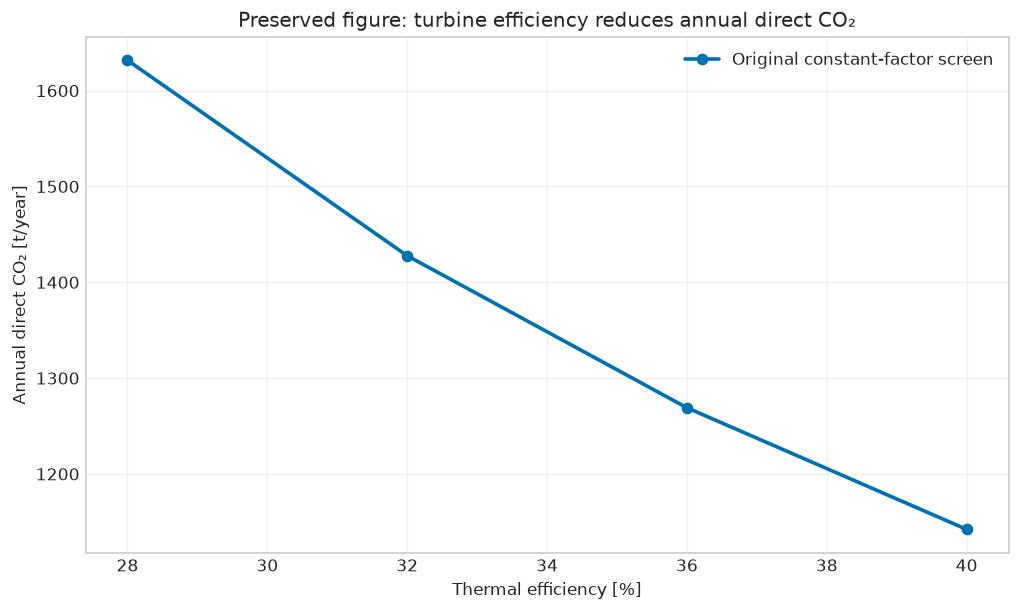

In [12]:
preserved_efficiencies = np.array([0.28, 0.32, 0.36, 0.40])
preserved_sensitivity = pd.DataFrame(
    [
        constant_factor_screen(
            ideal_result["power_kW"],
            efficiency,
        )
        for efficiency in preserved_efficiencies
    ]
)

figure, axis = plt.subplots(figsize=(8.6, 5.2))
axis.plot(
    preserved_sensitivity["Thermal efficiency [-]"] * 100.0,
    preserved_sensitivity["Annual direct CO₂ [t/year]"],
    marker="o",
    linewidth=2.2,
    color="#0072B2",
    label="Original constant-factor screen",
)
axis.set_title(
    "Preserved figure: turbine efficiency reduces annual direct CO₂"
)
axis.set_xlabel("Thermal efficiency [%]")
axis.set_ylabel("Annual direct CO₂ [t/year]")
axis.legend()
axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(preserved_sensitivity.round(6))


In [13]:
annual_values = preserved_sensitivity[
    "Annual direct CO₂ [t/year]"
].to_numpy()
assert np.all(np.diff(annual_values) < 0.0)

reduction_percent = 100.0 * (
    1.0 - annual_values[-1] / annual_values[0]
)
print(
    "Raising screening efficiency from 28% to 40% lowers annual direct "
    f"CO₂ by {reduction_percent:.3f}% at unchanged shaft power."
)


Raising screening efficiency from 28% to 40% lowers annual direct CO₂ by 30.000% at unchanged shaft power.


The original trend remains valid, but a real gas turbine does not have constant efficiency
across load. The next sections use the implemented NeqSim turbine functionality.


## 9. Current NeqSim gas-turbine catalog

`GasTurbineCatalog` exposes generic aeroderivative and industrial turbine specifications.
Rated power, heat rate, exhaust conditions, NOₓ reference, mass, and description are
available to Python through the Java API.


In [14]:
catalog_rows = []

for specification in GasTurbineCatalog.sortedByPower():
    catalog_rows.append(
        {
            "Model": str(specification.getModel()),
            "Type": str(specification.getType()),
            "Rated power [MW]": specification.getRatedPowerMW(),
            "Heat rate [kJ/kWh]": (
                specification.getHeatRateKJPerKWh()
            ),
            "ISO efficiency [%]": (
                100.0 * specification.getIsoEfficiency()
            ),
            "Exhaust flow [kg/s]": (
                specification.getExhaustFlowKgPerS()
            ),
            "Exhaust temperature [°C]": (
                specification.getExhaustTemperatureK() - 273.15
            ),
            "Reference NOₓ [ppm]": specification.getNoxPpmDLE(),
        }
    )

catalog_table = pd.DataFrame(catalog_rows)
display(catalog_table.round(3))
print(f"Catalog models available: {len(catalog_table)}")


Catalog models available: 17


,Model,Type,Rated power [MW],Heat rate [kJ/kWh],ISO efficiency [%],Exhaust flow [kg/s],Exhaust temperature [°C],Reference NOₓ [ppm]
0,CENTAUR_50,INDUSTRIAL,4.6,12180.0,29.557,18.6,510.0,25.0
1,TAURUS_60,INDUSTRIAL,5.7,11430.0,31.496,22.0,510.0,25.0
2,TAURUS_70,INDUSTRIAL,8.0,10240.0,35.156,27.0,490.0,25.0
3,MARS_100,INDUSTRIAL,10.7,10760.0,33.457,42.5,485.0,25.0
4,TITAN_130,INDUSTRIAL,15.0,10240.0,35.156,49.8,490.0,25.0
5,LM2500,AERODERIVATIVE,22.4,9700.0,37.113,70.5,545.0,25.0
6,TITAN_250,INDUSTRIAL,22.4,9245.0,38.940,68.0,465.0,15.0
7,LM2500PLUS_G4,AERODERIVATIVE,32.0,9085.0,39.626,88.4,510.0,25.0
8,RB211_6562,AERODERIVATIVE,32.0,9450.0,38.095,98.5,490.0,42.0
9,SGT_700,INDUSTRIAL,33.0,9695.0,37.133,95.0,525.0,15.0


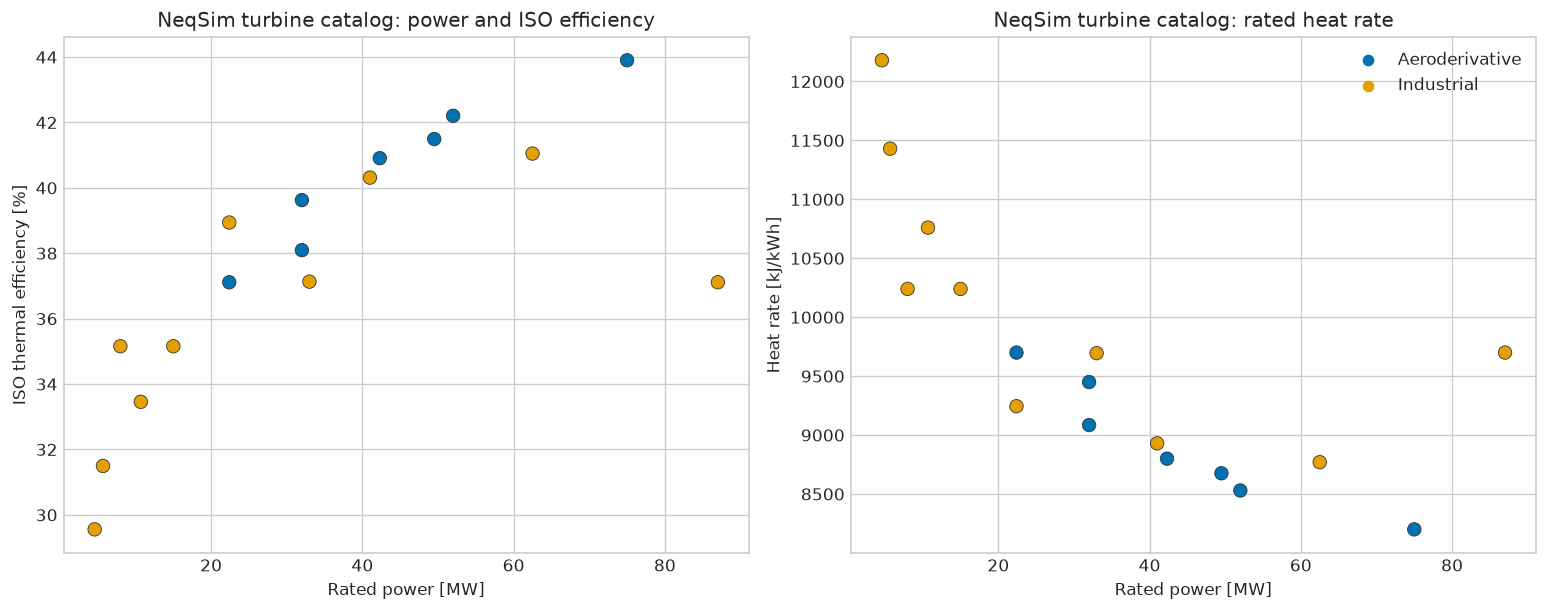

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
colors = catalog_table["Type"].map(
    {
        "AERODERIVATIVE": "#0072B2",
        "INDUSTRIAL": "#E69F00",
    }
)

axes[0].scatter(
    catalog_table["Rated power [MW]"],
    catalog_table["ISO efficiency [%]"],
    c=colors,
    s=65,
    edgecolor="#333333",
    linewidth=0.5,
)
axes[0].set_title("NeqSim turbine catalog: power and ISO efficiency")
axes[0].set_xlabel("Rated power [MW]")
axes[0].set_ylabel("ISO thermal efficiency [%]")

axes[1].scatter(
    catalog_table["Rated power [MW]"],
    catalog_table["Heat rate [kJ/kWh]"],
    c=colors,
    s=65,
    edgecolor="#333333",
    linewidth=0.5,
)
axes[1].set_title("NeqSim turbine catalog: rated heat rate")
axes[1].set_xlabel("Rated power [MW]")
axes[1].set_ylabel("Heat rate [kJ/kWh]")

for turbine_type, color in [
    ("Aeroderivative", "#0072B2"),
    ("Industrial", "#E69F00"),
]:
    axes[1].scatter(
        [],
        [],
        color=color,
        label=turbine_type,
    )

axes[1].legend()
plt.tight_layout()
plt.show()


Heat rate is fuel-energy input per electrical or shaft-energy output. Lower heat rate and
higher efficiency are preferable, but rated power, part-load behavior, ambient derating,
redundancy, exhaust conditions, and maintainability also affect selection.


## 10. Native `GasTurbineUnit` performance

The smallest catalog machine, `CENTAUR_50`, is used because the practical demand is a few
megawatts. Its performance map varies available power and heat rate with load and ambient
conditions. Native emissions use the actual fuel-gas carbon composition.


In [16]:
selected_model = "CENTAUR_50"
selected_specification = GasTurbineCatalog.get(selected_model)


def simulate_turbine(
    demand_mw,
    ambient_temperature_c=15.0,
    degradation=None,
    case_name="gas turbine",
):
    fuel_fluid = make_gas(
        temperature_c=15.0,
        pressure_bara=25.0,
        flow_kg_h=1_000.0,
    )
    fuel_stream = Stream(f"{case_name} fuel", fuel_fluid)
    turbine = GasTurbineUnit(
        case_name,
        fuel_stream,
        selected_specification,
    )
    turbine.setAmbientTemperatureK(
        ambient_temperature_c + 273.15
    )
    turbine.setAmbientPressureBara(1.01325)

    if degradation is not None:
        turbine.setDegradation(degradation)

    turbine.setDemandedPower(demand_mw * 1.0e6)
    turbine.run()
    result = {
        "Demand [MW]": demand_mw,
        "Available power [MW]": (
            turbine.getAvailablePowerW() / 1.0e6
        ),
        "Load [%]": 100.0 * turbine.getLoadFraction(),
        "Thermal efficiency [%]": (
            100.0 * turbine.getThermalEfficiency()
        ),
        "Heat rate [kJ/kWh]": (
            turbine.getEffectiveHeatRateKJPerKWh()
        ),
        "Fuel [kg/h]": turbine.getFuelMassFlowKgPerHr(),
        "CO₂ [kg/h]": turbine.getCO2EmissionKgPerHr(),
        "CO₂ intensity [kg/MWh]": (
            turbine.getCO2IntensityKgPerMWh()
        ),
        "NOₓ [kg/h]": turbine.getNOxEmissionKgPerS() * 3600.0,
        "Exhaust flow [kg/s]": (
            turbine.getExhaustMassFlowKgPerS()
        ),
        "Exhaust temperature [°C]": (
            turbine.getExhaustTemperatureK() - 273.15
        ),
        "Below minimum load": turbine.isBelowMinLoad(),
        "Overloaded": turbine.isOverloaded(),
    }
    return result, turbine


In [17]:
load_demands_mw = np.linspace(1.0, 4.4, 12)
load_results = []

for demand_mw in load_demands_mw:
    result, _ = simulate_turbine(
        demand_mw=demand_mw,
        case_name=f"load case {demand_mw:.2f} MW",
    )
    load_results.append(result)

load_table = pd.DataFrame(load_results)
display(load_table.round(4))


,Demand [MW],Available power [MW],Load [%],Thermal efficiency [%],Heat rate [kJ/kWh],Fuel [kg/h],CO₂ [kg/h],CO₂ intensity [kg/MWh],NOₓ [kg/h],Exhaust flow [kg/s],Exhaust temperature [°C],Below minimum load,Overloaded
0,1.0000,4.6,21.7391,20.3791,17665.1444,381.5081,1018.0500,1018.0500,1.6334,11.3217,437.9710,True,False
1,1.3091,4.6,28.4585,21.7891,16522.0331,467.1108,1246.4797,952.1720,1.7235,11.9466,455.8893,True,False
2,1.6182,4.6,35.1779,23.2180,15505.1847,541.8647,1445.9597,893.5706,1.8137,12.5715,473.8076,True,False
3,1.9273,4.6,41.8972,24.6329,14614.5993,608.2984,1623.2373,842.2458,1.9038,13.1964,491.7260,False,False
4,2.2364,4.6,48.6166,25.9923,13850.2769,668.9405,1785.0599,798.1975,1.9940,13.8213,509.6443,False,False
5,2.5455,4.6,55.3360,27.2475,13212.2174,726.3194,1938.1749,761.4259,2.0841,14.4462,527.5626,False,False
6,2.8545,4.6,62.0553,28.3455,12700.4208,782.9638,2089.3298,731.9308,2.1743,15.0711,538.4585,False,False
7,3.1636,4.6,68.7747,29.2329,12314.8873,841.4021,2245.2718,709.7123,2.2644,15.6960,533.4190,False,False
8,3.4727,4.6,75.4941,29.4125,12239.6964,917.9688,2449.5891,705.3791,2.3546,16.3209,528.3794,False,False
9,3.7818,4.6,82.2134,29.4519,12223.3281,998.3359,2664.0479,704.4357,2.4447,16.9458,523.3399,False,False


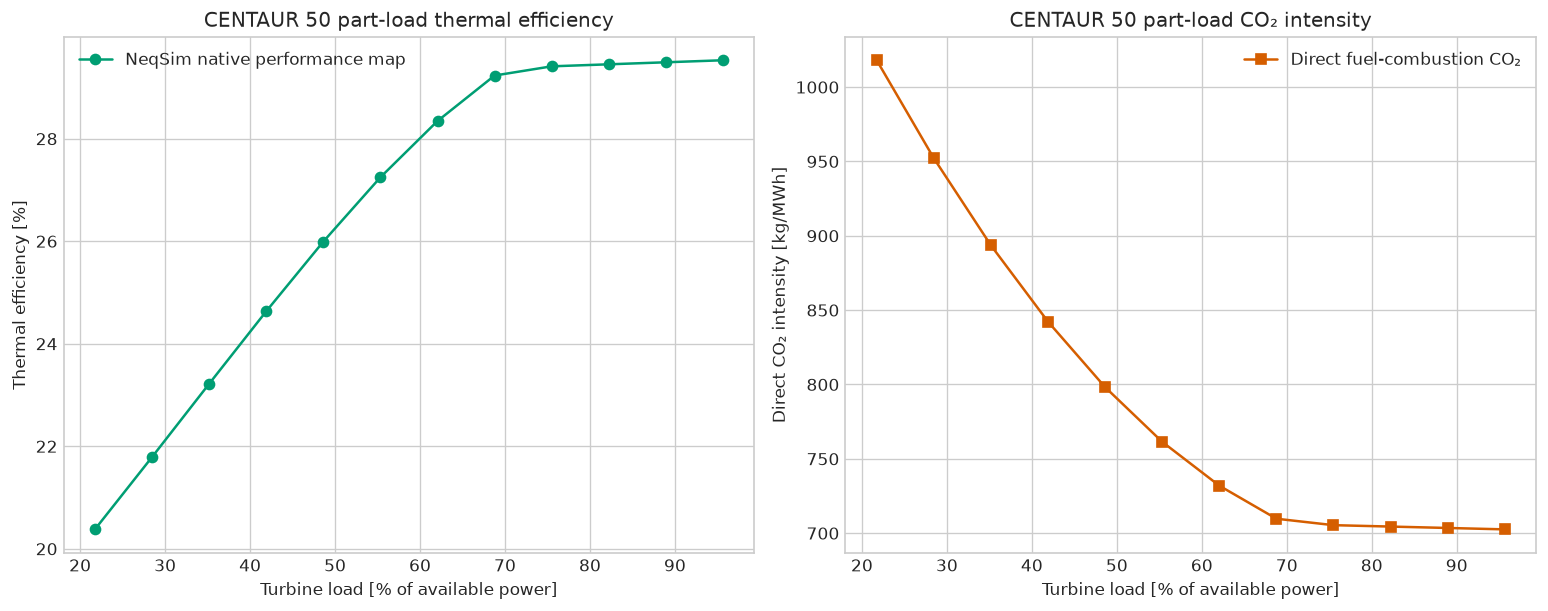

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
axes[0].plot(
    load_table["Load [%]"],
    load_table["Thermal efficiency [%]"],
    marker="o",
    color="#009E73",
    label="NeqSim native performance map",
)
axes[0].set_title("CENTAUR 50 part-load thermal efficiency")
axes[0].set_xlabel("Turbine load [% of available power]")
axes[0].set_ylabel("Thermal efficiency [%]")
axes[0].legend()

axes[1].plot(
    load_table["Load [%]"],
    load_table["CO₂ intensity [kg/MWh]"],
    marker="s",
    color="#D55E00",
    label="Direct fuel-combustion CO₂",
)
axes[1].set_title("CENTAUR 50 part-load CO₂ intensity")
axes[1].set_xlabel("Turbine load [% of available power]")
axes[1].set_ylabel("Direct CO₂ intensity [kg/MWh]")
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
high_load = load_table[load_table["Load [%]"] >= 60.0]
assert np.all(
    np.diff(high_load["CO₂ intensity [kg/MWh]"].to_numpy()) < 0.0
)
assert (load_table["Fuel [kg/h]"] > 0.0).all()
assert (load_table["CO₂ [kg/h]"] > 0.0).all()
assert not load_table["Overloaded"].any()

print(
    "Fuel and CO₂ are finite and positive; CO₂ intensity decreases "
    "across the validated 60–96% load range."
)


Fuel and CO₂ are finite and positive; CO₂ intensity decreases across the validated 60–96% load range.


The native curve explains why the constant 32% screen can be optimistic at low load.
Efficiency improves as the machine approaches its useful operating range, reducing
kilograms of direct CO₂ per megawatt-hour.


## 11. Ambient temperature and degradation

Gas-turbine available power generally falls as inlet air temperature rises. Fouling and
accumulated fired hours can further reduce capacity and increase heat rate. NeqSim exposes
these effects through ambient correction and `GasTurbineDegradation`.


In [20]:
ambient_temperatures_c = np.array([0.0, 10.0, 15.0, 25.0, 35.0, 40.0])
ambient_results = []

for ambient_temperature_c in ambient_temperatures_c:
    result, _ = simulate_turbine(
        demand_mw=3.0,
        ambient_temperature_c=ambient_temperature_c,
        case_name=f"ambient {ambient_temperature_c:.0f} C",
    )
    result["Condition"] = "Clean"
    result["Ambient temperature [°C]"] = ambient_temperature_c
    ambient_results.append(result)

degradation = GasTurbineDegradation()
degradation.setHoursSinceWash(8_000.0)
degradation.setHoursSinceOverhaul(30_000.0)

for ambient_temperature_c in ambient_temperatures_c:
    result, _ = simulate_turbine(
        demand_mw=3.0,
        ambient_temperature_c=ambient_temperature_c,
        degradation=degradation,
        case_name=f"degraded {ambient_temperature_c:.0f} C",
    )
    result["Condition"] = "Degraded"
    result["Ambient temperature [°C]"] = ambient_temperature_c
    ambient_results.append(result)

ambient_table = pd.DataFrame(ambient_results)
display(
    ambient_table[
        [
            "Condition",
            "Ambient temperature [°C]",
            "Available power [MW]",
            "Thermal efficiency [%]",
            "CO₂ intensity [kg/MWh]",
        ]
    ].round(4)
)


,Condition,Ambient temperature [°C],Available power [MW],Thermal efficiency [%],CO₂ intensity [kg/MWh]
0,Clean,0.0,4.9450,28.3898,730.7904
1,Clean,10.0,4.7150,28.6598,723.9047
2,Clean,15.0,4.6000,28.7925,720.5686
3,Clean,25.0,4.3700,29.0444,714.3191
4,Clean,35.0,4.1400,29.0462,714.2741
5,Clean,40.0,4.0250,28.9723,716.0965
6,Degraded,0.0,4.8362,27.3941,757.3513
7,Degraded,10.0,4.6113,27.6415,750.5728
8,Degraded,15.0,4.4988,27.7610,747.3415
9,Degraded,25.0,4.2739,27.9822,741.4335


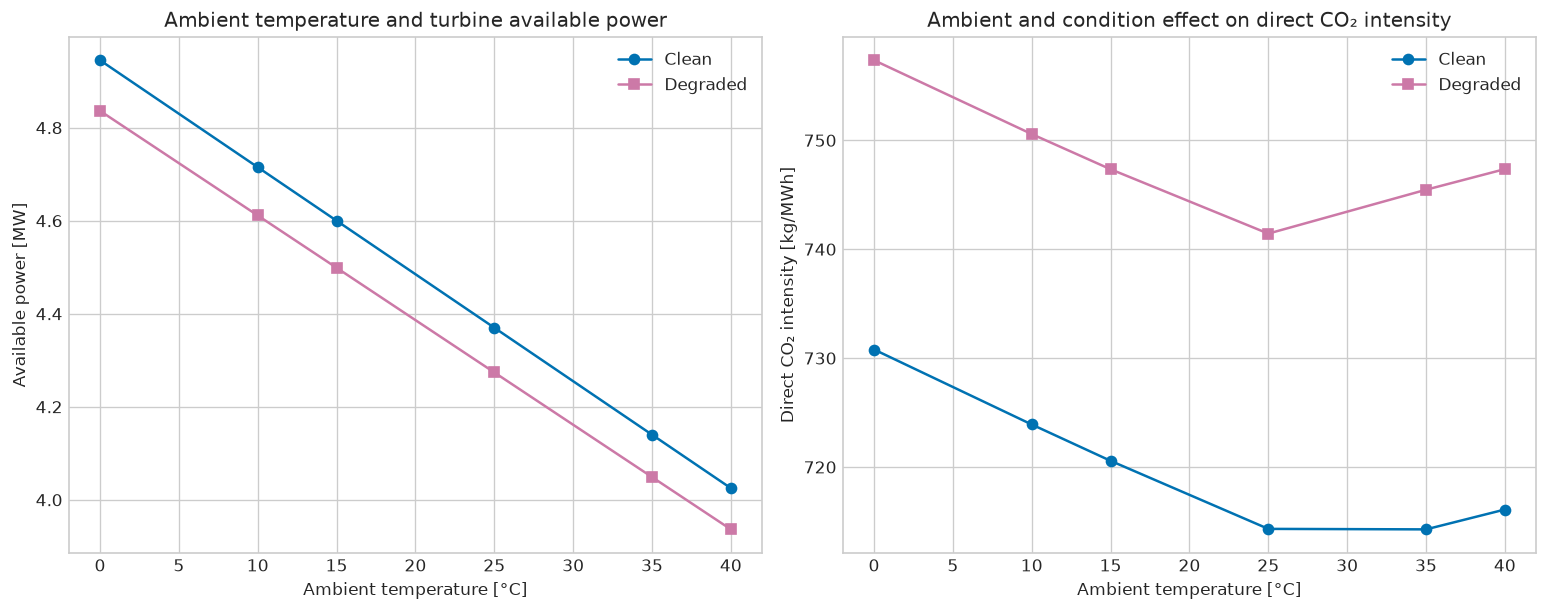

In [21]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))

for condition, color, marker in [
    ("Clean", "#0072B2", "o"),
    ("Degraded", "#CC79A7", "s"),
]:
    subset = ambient_table[ambient_table["Condition"] == condition]
    axes[0].plot(
        subset["Ambient temperature [°C]"],
        subset["Available power [MW]"],
        marker=marker,
        color=color,
        label=condition,
    )
    axes[1].plot(
        subset["Ambient temperature [°C]"],
        subset["CO₂ intensity [kg/MWh]"],
        marker=marker,
        color=color,
        label=condition,
    )

axes[0].set_title("Ambient temperature and turbine available power")
axes[0].set_xlabel("Ambient temperature [°C]")
axes[0].set_ylabel("Available power [MW]")
axes[0].legend()

axes[1].set_title("Ambient and condition effect on direct CO₂ intensity")
axes[1].set_xlabel("Ambient temperature [°C]")
axes[1].set_ylabel("Direct CO₂ intensity [kg/MWh]")
axes[1].legend()

plt.tight_layout()
plt.show()


In [22]:
clean_ambient = ambient_table[
    ambient_table["Condition"] == "Clean"
].sort_values("Ambient temperature [°C]")
clean_power = clean_ambient["Available power [MW]"].to_numpy()
degraded_15 = ambient_table[
    (ambient_table["Condition"] == "Degraded")
    & (ambient_table["Ambient temperature [°C]"] == 15.0)
].iloc[0]
clean_15 = ambient_table[
    (ambient_table["Condition"] == "Clean")
    & (ambient_table["Ambient temperature [°C]"] == 15.0)
].iloc[0]

assert np.all(np.diff(clean_power) < 0.0)
assert degraded_15["Available power [MW]"] < clean_15[
    "Available power [MW]"
]
assert degraded_15["CO₂ intensity [kg/MWh]"] > clean_15[
    "CO₂ intensity [kg/MWh]"
]

print("Ambient derating and degradation trend checks passed.")


Ambient derating and degradation trend checks passed.


The clean turbine loses available capacity as ambient temperature rises. The documented
degradation state also increases emissions intensity. These results are suitable for
scenario screening, not for replacing an OEM corrected-performance deck.


## 12. Constant-factor screen versus native NeqSim

Both methods are evaluated at 3 MW and 15 °C. The screen retains the original 32%
efficiency and fixed 2.75 kg/kg factor; the native model uses its load-dependent heat rate
and the six-component fuel assay.


In [23]:
comparison_demand_mw = 3.0
screening_at_3_mw = constant_factor_screen(
    comparison_demand_mw * 1000.0,
    screening_efficiency,
)
native_at_3_mw, native_at_3_mw_unit = simulate_turbine(
    demand_mw=comparison_demand_mw,
    ambient_temperature_c=15.0,
    case_name="native comparison",
)
native_carbon_factor = (
    native_at_3_mw["CO₂ [kg/h]"]
    / native_at_3_mw["Fuel [kg/h]"]
)

method_comparison = pd.DataFrame(
    [
        {
            "Method": "Original constant-factor screen",
            "Efficiency [%]": 100.0 * screening_efficiency,
            "Fuel [kg/h]": screening_at_3_mw["Fuel rate [kg/h]"],
            "CO₂ [kg/h]": (
                screening_at_3_mw["Fuel rate [kg/h]"]
                * screening_co2_factor_kg_per_kg
            ),
            "CO₂ factor [kg/kg fuel]": (
                screening_co2_factor_kg_per_kg
            ),
        },
        {
            "Method": "Native NeqSim GasTurbineUnit",
            "Efficiency [%]": native_at_3_mw[
                "Thermal efficiency [%]"
            ],
            "Fuel [kg/h]": native_at_3_mw["Fuel [kg/h]"],
            "CO₂ [kg/h]": native_at_3_mw["CO₂ [kg/h]"],
            "CO₂ factor [kg/kg fuel]": native_carbon_factor,
        },
    ]
)
display(method_comparison.round(4))


,Method,Efficiency [%],Fuel [kg/h],CO₂ [kg/h],CO₂ factor [kg/kg fuel]
0,Original constant-factor screen,32.0000,703.1250,1933.5938,2.7500
1,Native NeqSim GasTurbineUnit,28.7925,810.0863,2161.7059,2.6685


The difference is explainable rather than an error: the turbine is at part load, so native
efficiency differs from 32%, and the fuel-composition carbon factor differs from 2.75
kg/kg. A transparent screen remains useful early in a study; the native model is more
reusable for operating scenarios.


## 13. Final application: compressor-to-turbine workflow

A larger 80,000 kg/h export-compression case produces a demand in the useful range of the
smallest catalog turbine. The workflow:

1. creates and flashes a fresh SRK process gas;
2. runs a 78% efficient compressor from 55 to 120 bara;
3. creates a separate fuel-gas stream;
4. adds the compressor as a native turbine power consumer;
5. retrieves power, load, fuel, CO₂, NOₓ, and exhaust results; and
6. checks balances, capacity, and operating range.

The compressor is initialized first, then the turbine is added to the same `ProcessSystem`.
This staged steady-state execution ensures its calculated power is available to the power
consumer before turbine dispatch.


In [24]:
def run_integrated_application(
    process_flow_kg_h=80_000.0,
    ambient_temperature_c=15.0,
):
    process_result, process_objects = simulate_compressor(
        flow_kg_h=process_flow_kg_h,
        inlet_pressure_bara=55.0,
        outlet_pressure_bara=120.0,
        isentropic_efficiency=0.78,
        temperature_c=25.0,
        case_name="integrated export",
    )
    fuel_fluid = make_gas(
        temperature_c=15.0,
        pressure_bara=25.0,
        flow_kg_h=1_000.0,
    )
    fuel_stream = Stream("integrated fuel gas", fuel_fluid)
    turbine = GasTurbineUnit(
        "integrated CENTAUR 50",
        fuel_stream,
        selected_specification,
    )
    turbine.setAmbientTemperatureK(
        ambient_temperature_c + 273.15
    )
    turbine.setAmbientPressureBara(1.01325)
    turbine.addPowerConsumer(process_objects["compressor"])

    process = process_objects["process"]
    process.add(fuel_stream)
    process.run()
    process.add(turbine)
    process.run()

    application_result = {
        **process_result,
        "turbine_model": selected_model,
        "ambient_temperature_c": ambient_temperature_c,
        "turbine_demand_mw": (
            turbine.getDemandedPowerW() / 1.0e6
        ),
        "available_power_mw": (
            turbine.getAvailablePowerW() / 1.0e6
        ),
        "load_percent": 100.0 * turbine.getLoadFraction(),
        "turbine_efficiency_percent": (
            100.0 * turbine.getThermalEfficiency()
        ),
        "fuel_kg_h": turbine.getFuelMassFlowKgPerHr(),
        "co2_kg_h": turbine.getCO2EmissionKgPerHr(),
        "co2_intensity_kg_mwh": (
            turbine.getCO2IntensityKgPerMWh()
        ),
        "nox_kg_h": turbine.getNOxEmissionKgPerS() * 3600.0,
        "exhaust_flow_kg_s": turbine.getExhaustMassFlowKgPerS(),
        "exhaust_temperature_c": (
            turbine.getExhaustTemperatureK() - 273.15
        ),
        "below_minimum_load": turbine.isBelowMinLoad(),
        "overloaded": turbine.isOverloaded(),
        "power_shortfall_w": turbine.getPowerShortfallW(),
    }
    application_objects = {
        **process_objects,
        "fuel_stream": fuel_stream,
        "turbine": turbine,
        "process": process,
    }
    return application_result, application_objects


In [25]:
application_result, application_objects = run_integrated_application()

application_table = pd.DataFrame(
    [
        {
            "Process flow [kg/h]": application_result["flow_kg_h"],
            "Compressor power [MW]": (
                application_result["power_kW"] / 1000.0
            ),
            "Turbine available power [MW]": (
                application_result["available_power_mw"]
            ),
            "Turbine load [%]": application_result["load_percent"],
            "Turbine efficiency [%]": (
                application_result["turbine_efficiency_percent"]
            ),
            "Fuel [kg/h]": application_result["fuel_kg_h"],
            "Direct CO₂ [kg/h]": application_result["co2_kg_h"],
            "Direct CO₂ [t/year]": (
                application_result["co2_kg_h"]
                * annual_operating_hours
                / 1000.0
            ),
            "NOₓ [kg/h]": application_result["nox_kg_h"],
            "Exhaust flow [kg/s]": (
                application_result["exhaust_flow_kg_s"]
            ),
            "Exhaust temperature [°C]": (
                application_result["exhaust_temperature_c"]
            ),
        }
    ]
)
display(application_table.round(4))


,Process flow [kg/h],Compressor power [MW],Turbine available power [MW],Turbine load [%],Turbine efficiency [%],Fuel [kg/h],Direct CO₂ [kg/h],Direct CO₂ [t/year],NOₓ [kg/h],Exhaust flow [kg/s],Exhaust temperature [°C]
0,80000.0,2.8399,4.6,61.7368,28.2978,780.258,2082.1096,16656.8766,2.17,15.0415,538.6974


In [26]:
assert math.isclose(
    application_result["turbine_demand_mw"],
    application_result["power_kW"] / 1000.0,
    rel_tol=1.0e-10,
)
assert abs(application_result["mass_residual_kg_h"]) < 1.0e-6
assert abs(application_result["energy_residual_w"]) < 1.0e-5
assert application_result["power_shortfall_w"] == 0.0
assert not application_result["below_minimum_load"]
assert not application_result["overloaded"]
assert 50.0 < application_result["load_percent"] < 90.0
assert 0.0 < application_result["co2_kg_h"]
assert 0.0 < application_result["nox_kg_h"]

print("Integrated mass, energy, power-demand, capacity, and emissions checks passed.")


Integrated mass, energy, power-demand, capacity, and emissions checks passed.


,Value
Compressor demand [MW],2.839893
Available turbine power [MW],4.600000
Fuel rate [t/h],0.780258
Direct CO₂ [t/h],2.082110
Annual direct CO₂ [kt/year],16.656877


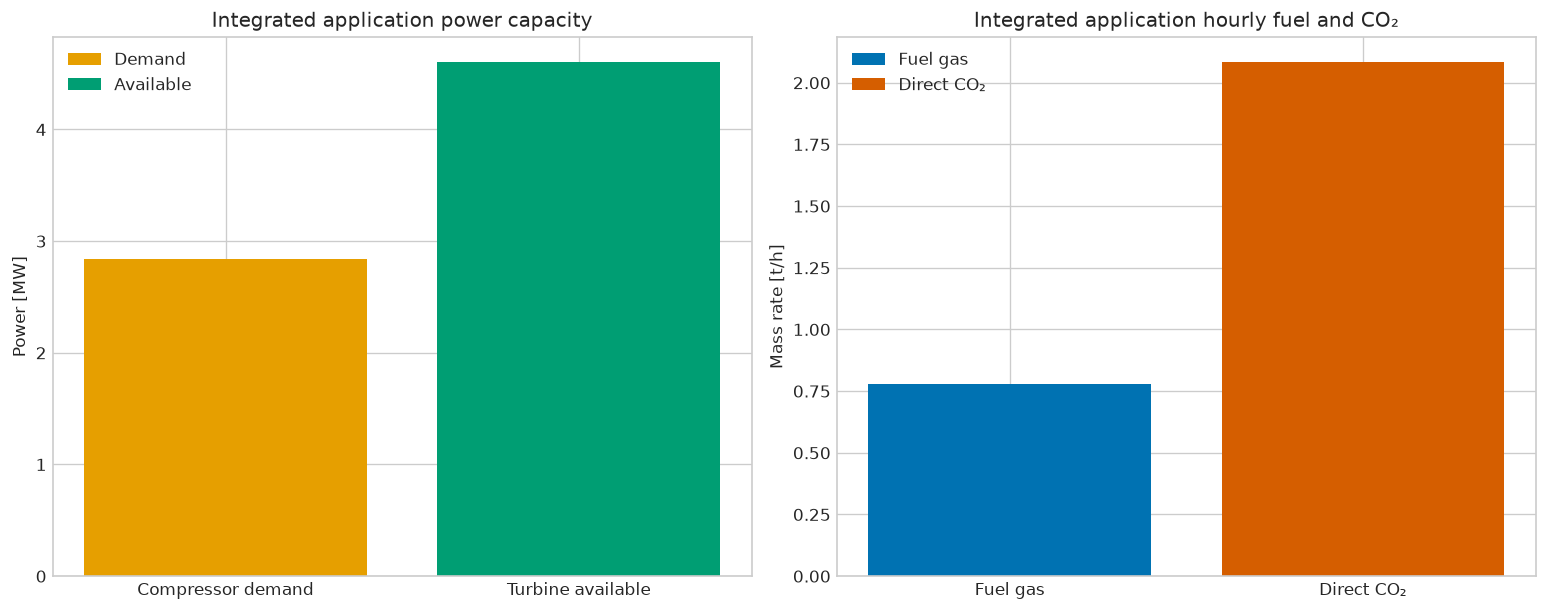

In [27]:
annual_co2_tonnes = (
    application_result["co2_kg_h"]
    * annual_operating_hours
    / 1000.0
)
application_metrics = pd.Series(
    {
        "Compressor demand [MW]": (
            application_result["turbine_demand_mw"]
        ),
        "Available turbine power [MW]": (
            application_result["available_power_mw"]
        ),
        "Fuel rate [t/h]": application_result["fuel_kg_h"] / 1000.0,
        "Direct CO₂ [t/h]": application_result["co2_kg_h"] / 1000.0,
        "Annual direct CO₂ [kt/year]": annual_co2_tonnes / 1000.0,
    }
)

figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
axes[0].bar(
    ["Compressor demand", "Turbine available"],
    [
        application_metrics["Compressor demand [MW]"],
        application_metrics["Available turbine power [MW]"],
    ],
    color=["#E69F00", "#009E73"],
    label=["Demand", "Available"],
)
axes[0].set_title("Integrated application power capacity")
axes[0].set_ylabel("Power [MW]")
axes[0].legend()

axes[1].bar(
    ["Fuel gas", "Direct CO₂"],
    [
        application_metrics["Fuel rate [t/h]"],
        application_metrics["Direct CO₂ [t/h]"],
    ],
    color=["#0072B2", "#D55E00"],
    label=["Fuel gas", "Direct CO₂"],
)
axes[1].set_title("Integrated application hourly fuel and CO₂")
axes[1].set_ylabel("Mass rate [t/h]")
axes[1].legend()

plt.tight_layout()
plt.show()

display(application_metrics.to_frame("Value").round(6))


The selected turbine has positive capacity margin and operates above its minimum-load
region. The direct-emissions result covers steady fuel combustion only. For a facility
inventory, add starts, trips, flaring, fugitives, imported power, and upstream boundaries.


## 14. Validation summary

Validation reaches the conservation-and-consistency level:

- composition closes to 1.0;
- the ideal compressor reproduces the previous result;
- realistic power scales as $1/\eta_c$;
- compressor mass and energy residuals close numerically;
- the preserved emissions table and four-point figure are reproduced;
- annual CO₂ decreases with screening efficiency;
- native high-load CO₂ intensity decreases with load;
- available power decreases with ambient temperature;
- degradation reduces capacity and increases intensity; and
- the integrated turbine demand equals calculated compressor power with no shortfall.

This is a transparent engineering tutorial, not a certified vendor performance test.


In [28]:
validation_checks = {
    "Composition closure": math.isclose(
        composition_sum,
        1.0,
        abs_tol=1.0e-12,
    ),
    "Preserved ideal compressor": 270.0 < ideal_result["power_kW"] < 285.0,
    "Mass closure": abs(application_result["mass_residual_kg_h"]) < 1.0e-6,
    "Energy closure": abs(application_result["energy_residual_w"]) < 1.0e-5,
    "Preserved sensitivity trend": bool(np.all(np.diff(annual_values) < 0.0)),
    "Ambient derating trend": bool(np.all(np.diff(clean_power) < 0.0)),
    "No turbine shortfall": application_result["power_shortfall_w"] == 0.0,
    "Useful turbine load": (
        50.0 < application_result["load_percent"] < 90.0
    ),
}

validation_table = pd.DataFrame(
    {
        "Check": list(validation_checks),
        "Passed": list(validation_checks.values()),
    }
)
display(validation_table)
assert all(validation_checks.values())
print(f"All {len(validation_checks)} final validation checks passed.")


All 8 final validation checks passed.


,Check,Passed
0,Composition closure,True
1,Preserved ideal compressor,True
2,Mass closure,True
3,Energy closure,True
4,Preserved sensitivity trend,True
5,Ambient derating trend,True
6,No turbine shortfall,True
7,Useful turbine load,True


## 15. Troubleshooting

- **Import fails:** rerun the setup cell in a fresh Colab runtime and confirm PyPI access.
- **Java does not start:** use a standard Colab CPU runtime and do not replace the bundled
  NeqSim JAR.
- **Compressor power is lower than expected:** verify whether efficiency was left at the
  ideal 1.0 default.
- **Turbine is below minimum load:** choose a smaller machine, aggregate demand, or model
  an operating fleet rather than trusting low-load efficiency.
- **Turbine is overloaded:** reduce demand, select a larger catalog unit, or add parallel
  units and redundancy.
- **Plant emissions differ:** reconcile fuel composition, LHV basis, load, ambient state,
  degradation, starts, flaring, and measurement boundaries.


## 16. Summary and reuse pattern

The original gas, compressor, factors, table, and figure remain operational. The repair
makes compressor efficiency explicit and adds current NeqSim turbine catalog, performance,
emissions, ambient, degradation, and native power-consumer functionality.

For reuse: define the gas and boundary, simulate equipment power, select a justified
turbine specification, connect power consumers, run operating scenarios, retrieve flat
KPIs, and keep conservation, capacity, and trend assertions beside the workflow.


## 17. Further exercises

1. Compare `CENTAUR_50` and `TAURUS_60` at the same 3 MW demand.
2. Add two compressors and evaluate N+1 turbine capacity.
3. Sweep fuel CO₂ and nitrogen while holding energy demand fixed.
4. Apply offline wash and major overhaul methods to the degradation object.
5. Add a documented fuel-price and carbon-price scenario.
6. Replace the generic map with an approved vendor curve before detailed design.


## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/)
- [NeqSim PyPI package](https://pypi.org/project/neqsim/)
- [NeqSim source repository](https://github.com/equinor/neqsim)
- ISO 3977-2, *Gas turbines — Procurement — Part 2: Standard reference conditions and
  ratings*.

Accessed 23 July 2026. The gas composition and screening factors are preserved synthetic
educational inputs; turbine catalog values are shipped with NeqSim 3.16.0.
